# Bootstrapping
## Paired, patient-level bootstrapping for confidence intervals

`C2_evaluation.ipynb` reports point estimates: one mean-fold AUROC per config. This notebook
puts an interval around the *differences between families*, and asks the ordering question
directly:


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

RESULTS = os.environ.get("THESIS_RESULTS", "/work3/s251710/thesis_results")
C2      = os.path.join(RESULTS, "C2_final_results")
SOURCE  = "knn_correct_cf"
MODEL   = "MLP"            # the estimator C2_evaluation.ipynb settles on

DISEASES = ["effusion", "atelectasis", "cardiomegaly", "consolidation", "edema"]
K_VALUES = [1, 5, 10]      # searched jointly with the config, as in Aim 2

# The three input families. B1.2 is left out (monotone transform of B1 -- same ranking).
FAMILIES = {
    "B":   ["B1", "B2", "B3", "B4", "B5"],
    "M":   ["M1", "M2", "M3", "M4", "M5", "M6"],
    "MCF": ["MCF1", "MCF2", "MCF3", "MCF4", "MCF5"],
}

# Every score column the bootstrap carries: the three family winners plus MSP, the
# untrained baseline C2_evaluation.ipynb measures everything against.
SCORES = list(FAMILIES) + ["MSP"]

N_BOOT, SEED = 1000, 0

BLUE, VERM, GREY, INK, MUTED, HAIR = "#0072B2", "#D55E00", "#BFBFBF", "#2D2D2D", "#2D2D2D", "#E8E8E8"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": MUTED, "axes.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.titlesize": 10, "axes.labelsize": 9,
})

## 1. Pick one model per family

Two AUROCs appear in this notebook and they are not the same statistic:

* **selection** uses the mean AUROC over the five folds, so the winner here is the same model
  the evaluation notebook draws;
* **the bootstrap below** uses the pooled AUROC over all out-of-fold rows, because once
  patients are resampled the fold structure no longer partitions anything.

They differ in the third decimal. Selection and evaluation are kept separate on purpose;
nothing is re-selected inside the bootstrap loop.

In [2]:
def load_attributes(disease, k, n_folds=5):
    """Pooled out-of-fold attribute predictions for one disease and one K."""
    parts = []
    for i in range(n_folds):
        p = os.path.join(C2, disease, SOURCE, f"cf_{k}", "attributes",
                         f"fold_{i}_predictions.csv")
        parts.append(pd.read_csv(p).assign(fold=i))
    return pd.concat(parts, ignore_index=True)


def per_fold_auc(df, col):
    """Mean AUROC over the 5 folds -- the statistic models are selected on."""
    return float(np.mean([roc_auc_score(g["correct"], g[col]) for _, g in df.groupby("fold")]))


def best_in_family(frames, configs):
    """The (config, K) in this family with the highest mean fold AUROC."""
    return max(((c, k, per_fold_auc(f, f"{MODEL}_{c}_prob"))
                for k, f in frames.items()
                for c in configs if f"{MODEL}_{c}_prob" in f.columns),
               key=lambda t: t[2])


def paired_table(disease):
    """One row per C2 sample; one score column per family, its best (config, K), plus MSP.

    Every K scores the same rows, so the three winners land in a single frame indexed by
    path -- which is what lets the bootstrap resample all three together.
    """
    frames = {k: load_attributes(disease, k).set_index("path") for k in K_VALUES}
    ref    = frames[K_VALUES[0]]
    out    = ref[["patient_id", "correct"]].copy()
    picks  = {}
    for fam, configs in FAMILIES.items():
        cfg, k, auc = best_in_family(frames, configs)
        out[fam]    = frames[k][f"{MODEL}_{cfg}_prob"]
        picks[fam]  = (cfg, k, auc)

    # MSP -- max(p, 1-p) straight off C0, nothing fitted. No config and no K to search,
    # so it is not a family; it is the reference the families are judged against, scored
    # on exactly the same rows.
    out["MSP"]   = np.maximum(ref[f"{disease}_prob"], 1 - ref[f"{disease}_prob"])
    picks["MSP"] = ("max(p,1-p)", "-", per_fold_auc(ref.assign(MSP=out["MSP"]), "MSP"))
    return out.reset_index(drop=True), picks


TABLES, PICKS = {}, {}
for d in DISEASES:
    TABLES[d], PICKS[d] = paired_table(d)

picks = pd.DataFrame([{"disease": d, "model": f, "config": c, "K": k,
                       "AUROC (mean fold)": round(a, 4),
                       "n": len(TABLES[d]), "n patients": TABLES[d].patient_id.nunique()}
                      for d, p in PICKS.items() for f, (c, k, a) in p.items()])
picks.set_index(["disease", "model"])

config   K  AUROC (mean fold)      n  n patients
disease       model                                                      
effusion      B              B1   1             0.7817  90934       31415
              M              M4  10             0.7785  90934       31415
              MCF          MCF5  10             0.7838  90934       31415
              MSP    max(p,1-p)   -             0.7803  90934       31415
atelectasis   B              B1   1             0.8613  80938       29572
              M              M4  10             0.8512  80938       29572
              MCF          MCF1  10             0.8632  80938       29572
              MSP    max(p,1-p)   -             0.8185  80938       29572
cardiomegaly  B              B1   1             0.9173  92507       31597
              M              M4  10             0.9118  92507       31597
              MCF          MCF4  10             0.9187  92507       31597
              MSP    max(p,1-p)   -             0.8952  92507       31597
consolidation B              B1   1             0.9436  83688       30287
              M              M5  10             0.9394  83688       30287
              MCF          MCF1  10             0.9457  83688       30287
              MSP    max(p,1-p)   -             0.9250  83688       30287
edema         B              B1   1             0.8300  89852       31235
              M              M4  10             0.8273  89852       31235
              MCF          MCF5  10             0.8341  89852       31235
              MSP    max(p,1-p)   -             0.8109  89852       31235

## 2. The bootstrap

`B` times over: draw a bootstrap sample of patients, then rescore every (disease, family) on
that draw.

Drawing a patient twice is *exactly* the same as giving each of its rows weight 2 in the
AUROC, and the weighted form is what is implemented: it avoids rebuilding a 90k-row index a
thousand times, and the AUROC of a resampled set is the weighted U statistic over the original
rows, ties and all.

The five diseases are scored on **one shared draw** per replicate rather than five independent
ones. They are built from the same CheXpert patients, so independent draws would pretend the
per-disease deltas are independent, and the interval on the disease average would come out too
narrow.

In [3]:
def bootstrap(tables, n_boot=N_BOOT, seed=SEED):
    """Paired patient-level bootstrap -> DataFrame of AUROCs, one row per replicate,
    columns (disease, model), where model is a family winner or MSP."""
    rng      = np.random.default_rng(seed)
    patients = pd.Index(sorted(set().union(*(set(t.patient_id) for t in tables.values()))))
    # Which patient each row belongs to, as a position in the shared patient list.
    codes    = {d: patients.get_indexer(t.patient_id) for d, t in tables.items()}

    reps = []
    for b in range(n_boot):
        # counts[p] = how many times patient p was drawn -> the weight of all its rows.
        counts = np.bincount(rng.integers(0, len(patients), len(patients)),
                             minlength=len(patients))
        reps.append({(d, m): roc_auc_score(t.correct, t[m], sample_weight=counts[codes[d]])
                     for d, t in tables.items() for m in SCORES})
        if (b + 1) % 100 == 0:
            print(f"\r{b + 1}/{n_boot} replicates", end="")

    out = pd.DataFrame(reps)
    out.columns = pd.MultiIndex.from_tuples(out.columns, names=["disease", "model"])
    return out


BOOT = bootstrap(TABLES)
BOOT.shape

1000/1000 replicates

(1000, 20)

## 3. The ordering question

Three deltas per replicate: `MCF - M`, `M - B`, and `MCF - B` for the whole chain. The
`AVERAGE` row averages the five per-disease deltas **inside each replicate** before taking
percentiles, so the interval on the average inherits the pairing rather than being stitched
together from five separate intervals.

`P(delta > 0)` is the share of replicates in which the higher family actually wins. It is the
one-sided bootstrap answer to "is this family better"; the 95% interval is the two-sided one.

In [4]:
def summarise(x):
    """Mean, 95% percentile interval, and the share of replicates above zero."""
    return {"delta": x.mean(), "lo": np.percentile(x, 2.5), "hi": np.percentile(x, 97.5),
            "P(delta>0)": (x > 0).mean()}


# The key comparisons

Sections 3-5 answer two questions: the family ordering, and whether the attribute models beat
MSP. This section puts the same machinery behind every comparison the thesis actually makes,
attributes and CNNs and ensembles together, in one table and one figure.

| # | Comparison | What it asks |
|---|---|---|
| 1 | `M - B` (family average) | do the counterfactual *deltas* help over query-only inputs? |
| 2 | `MCF - M` (family average) | does adding the counterfactual's own features help further? |
| 3 | `attr K=5 - K=1` | does pooling over 5 counterfactuals beat using 1? |
| 4 | `CNN K=5 - K=1` | the same question for the image models |
| 5 | `best attr - best CNN` | which modality reads correctness better? |
| 6 | `ensemble - best single` | is combining the two better than the better one alone? |
| 7 | `best overall - MSP` | does any of this beat raw confidence? |

**Averages vs winners.** 1 and 2 average the AUROC over *all* configs in a family, which is
the question "does this class of input help", not "does its best member win"; section 3 already
compares the family winners, and the two can disagree. 3-7 are single models, each the argmax
of mean fold AUROC over its candidate set.

**Selection is never done inside the bootstrap.** Every model here is chosen once, on the mean
fold AUROC of the real data, exactly as `C2_evaluation.ipynb` chooses the models it plots. The
resampling then re-scores those fixed models, so the intervals are intervals on the chosen
models, not on the selection procedure.

**Two restrictions worth stating.** The `K=5 vs K=1` rows only consider models whose *inputs*
depend on the counterfactuals -- `M*`/`MCF*` on the attribute side, and everything but
`xi`/`xi_sal` on the image side. The others score identically at every K by construction, so
including them would dilute the comparison with exact zeros. And the config for a K comparison
is picked on the *mean of its two arms*, so neither K is favoured by the selection.

**A K row is about the winning config, not about K in general.** The config that wins both arms
need not be the one K helps most - a config that is already strong at K=1 has less to gain from
pooling - so a small delta here means "the best model barely improves", not "K does nothing".
The per-config picture across every K is the Aim 1 ladder in `C2_evaluation.ipynb`.

In [5]:
CNN_KEYS    = ["xi", "xi_sal", "cf", "cf_sal", "dual", "dual_sal", "dual_sal_scalars"]
CNN_CF_KEYS = ["cf", "cf_sal", "dual", "dual_sal", "dual_sal_scalars"]   # see the note above
CF_CONFIGS  = FAMILIES["M"] + FAMILIES["MCF"]                            # ditto, attribute side
CONFIGS     = [c for cs in FAMILIES.values() for c in cs]
K_LOW, K_HIGH = 1, 5    # the two arms of the K comparisons
K_AVG         = 10    # the K the family averages are taken at


def load_cnn(disease, k, key, n_folds=5):
    """Pooled out-of-fold predictions of one CNN variant, as a Series indexed by path."""
    parts = [pd.read_csv(os.path.join(C2, disease, SOURCE, f"cf_{k}", "images", key,
                                      f"fold_{i}_predictions.csv")) for i in range(n_folds)]
    return pd.concat(parts, ignore_index=True).set_index("path")[f"{key}_prob"]


def load_ensemble(disease, k):
    """Out-of-fold ensemble predictions written by c2_ensemble.py: the `ens_*` combiners
    and the two component models they combine. Nothing is fitted here."""
    return pd.read_csv(os.path.join(C2, disease, SOURCE, f"cf_{k}", "ensemble",
                                    "oof_predictions.csv")).set_index("path")


# Column names for the score table. One namespace for all three model types, so a
# comparison is just a pair of column lists.
def attr_col(config, k): return f"{config}@K{k}"
def cnn_col(key, k):     return f"CNN {key}@K{k}"
def ens_col(method, k):  return f"ENS {method}@K{k}"

def cmp_specs(p):
    """The seven comparisons, as (name, columns_high, columns_low) for one disease."""
    return [
        ("M - B (family average)",       p["M"],           p["B"]),
        ("MCF - M (family average)",     p["MCF"],         p["M"]),
        ("MCF - B (family average)",     p["MCF"],         p["B"]),
        # CHANGED: Now using the full lists of all CF configs at K=5 vs K=1
        (f"attr K={K_HIGH} - K={K_LOW} (avg)", p["attr_hi_all"], p["attr_lo_all"]),
        (f"CNN K={K_HIGH} - K={K_LOW} (avg)",  p["cnn_hi_all"],  p["cnn_lo_all"]),
        ("best attr - best CNN",         [p["best_attr"]], [p["best_cnn"]]),
        ("ensemble - best single",       [p["best_ens"]],  [p["best_comp"]]),
        ("best overall - MSP",           [p["best_all"]],  ["MSP"]),
    ]

## 7.1 Pick the models

One pass per disease: score every candidate on mean fold AUROC, then record which column each
comparison needs. The table below is the whole selection, printed so nothing about the figure
later has to be taken on trust -- `best_comp` is the stronger of the two models the ensemble
combines, and `best_all` is the best of {best attribute, best CNN, best ensemble}.

Runs in about a minute: it scores every config, variant and combiner at every K.

In [6]:
def cmp_select(disease):
    """Score every candidate, choose the models the comparisons need, and return the
    narrow table of just those score columns.

    Returns (table, picks, aucs): `table` is one row per C2 sample with one column per
    score used below; `picks` maps a role in cmp_specs to column name(s); `aucs` is the
    selection AUROC of every candidate, kept so the printed table can show them.
    """
    attr = {k: load_attributes(disease, k).set_index("path") for k in K_VALUES}
    ref  = attr[K_VALUES[0]]
    base = ref[["correct", "fold"]]          # small frame to score against
    cols, aucs = {}, {}

    def add(name, series):
        cols[name] = series.reindex(ref.index)        # every model scores the same rows
        aucs[name] = per_fold_auc(base.assign(_s=cols[name]), "_s")

    for k in K_VALUES:
        for c in CONFIGS:
            add(attr_col(c, k), attr[k][f"{MODEL}_{c}_prob"])
        for key in CNN_KEYS:
            add(cnn_col(key, k), load_cnn(disease, k, key))
        ens = load_ensemble(disease, k)
        for m in [c for c in ens.columns if c.startswith("ens_")]:
            add(ens_col(m[len("ens_"):], k), ens[m])
    add("MSP", np.maximum(ref[f"{disease}_prob"], 1 - ref[f"{disease}_prob"]))

    best = lambda names: max(names, key=aucs.get)
    p = {fam: [attr_col(c, K_AVG) for c in cs] for fam, cs in FAMILIES.items()}

    # K comparisons: pick the config on the MEAN of its two arms, so the choice does not
    # itself favour K=1 or K=5, and only among models whose inputs depend on the CFs.
    # WITH THIS:
    p["attr_lo_all"] = [attr_col(c, K_LOW) for c in CF_CONFIGS]
    p["attr_hi_all"] = [attr_col(c, K_HIGH) for c in CF_CONFIGS]

    p["cnn_lo_all"]  = [cnn_col(x, K_LOW) for x in CNN_CF_KEYS]
    p["cnn_hi_all"]  = [cnn_col(x, K_HIGH) for x in CNN_CF_KEYS]

    p["best_attr"] = best([attr_col(c, k) for k in K_VALUES for c in CONFIGS])
    p["best_cnn"]  = best([cnn_col(x, k) for k in K_VALUES for x in CNN_KEYS])
    p["best_ens"]  = best([n for n in cols if n.startswith("ENS ")])

    # The ensemble's own two components, at the K the winning combiner was run at. They are
    # bit-identical to the attribute and CNN columns already in the table, so the comparison
    # reuses those rather than adding a second copy under a different name.
    k_ens = int(p["best_ens"].split("@K")[1])
    comps = [c for c in load_ensemble(disease, k_ens).columns
             if c not in ("patient_id", "fold", "correct") and not c.startswith("ens_")]
    p["best_comp"] = best([attr_col(c[len(MODEL) + 1:-len("_prob")], k_ens) if c.startswith(MODEL + "_")
                           else cnn_col(c[:-len("_prob")], k_ens) for c in comps])
    p["best_all"]  = best([p["best_attr"], p["best_cnn"], p["best_ens"]])

    used  = sorted({c for _, hi, lo in cmp_specs(p) for c in hi + lo})
    table = pd.DataFrame({c: cols[c] for c in used})
    table["correct"], table["patient_id"] = ref["correct"], ref["patient_id"]
    return table.reset_index(drop=True), p, aucs


CMP_TABLES, CMP_PICKS, CMP_AUCS = {}, {}, {}
for d in DISEASES:
    CMP_TABLES[d], CMP_PICKS[d], CMP_AUCS[d] = cmp_select(d)
    print(f"{d}: {len(CMP_TABLES[d]):,} rows, {CMP_TABLES[d].patient_id.nunique():,} patients")

CMP_NAMES = [n for n, _, _ in cmp_specs(CMP_PICKS[DISEASES[0]])]

pd.DataFrame([{"disease": d, "role": role,
               "model": " + ".join(v) if isinstance(v, list) else v,
               "AUROC (mean fold)": round(np.mean([CMP_AUCS[d][c] for c in np.atleast_1d(v)]), 4)}
              for d, p in CMP_PICKS.items() for role, v in p.items()]
            ).set_index(["disease", "role"])

effusion: 90,934 rows, 31,415 patients
atelectasis: 80,938 rows, 29,572 patients
cardiomegaly: 92,507 rows, 31,597 patients
consolidation: 83,688 rows, 30,287 patients
edema: 89,852 rows, 31,235 patients


model  \
disease       role                                                             
effusion      B                   B1@K10 + B2@K10 + B3@K10 + B4@K10 + B5@K10   
              M            M1@K10 + M2@K10 + M3@K10 + M4@K10 + M5@K10 + M...   
              MCF          MCF1@K10 + MCF2@K10 + MCF3@K10 + MCF4@K10 + MC...   
              attr_lo_all  M1@K1 + M2@K1 + M3@K1 + M4@K1 + M5@K1 + M6@K1 ...   
              attr_hi_all  M1@K5 + M2@K5 + M3@K5 + M4@K5 + M5@K5 + M6@K5 ...   
              cnn_lo_all   CNN cf@K1 + CNN cf_sal@K1 + CNN dual@K1 + CNN ...   
              cnn_hi_all   CNN cf@K5 + CNN cf_sal@K5 + CNN dual@K5 + CNN ...   
              best_attr                                             MCF5@K10   
              best_cnn                              CNN dual_sal_scalars@K10   
              best_ens                                          ENS rank@K10   
              best_comp                                             MCF5@K10   
              best_all                                          ENS rank@K10   
atelectasis   B                   B1@K10 + B2@K10 + B3@K10 + B4@K10 + B5@K10   
              M            M1@K10 + M2@K10 + M3@K10 + M4@K10 + M5@K10 + M...   
              MCF          MCF1@K10 + MCF2@K10 + MCF3@K10 + MCF4@K10 + MC...   
              attr_lo_all  M1@K1 + M2@K1 + M3@K1 + M4@K1 + M5@K1 + M6@K1 ...   
              attr_hi_all  M1@K5 + M2@K5 + M3@K5 + M4@K5 + M5@K5 + M6@K5 ...   
              cnn_lo_all   CNN cf@K1 + CNN cf_sal@K1 + CNN dual@K1 + CNN ...   
              cnn_hi_all   CNN cf@K5 + CNN cf_sal@K5 + CNN dual@K5 + CNN ...   
              best_attr                                             MCF1@K10   
              best_cnn                              CNN dual_sal_scalars@K10   
              best_ens                                            ENS lr@K10   
              best_comp                                             MCF1@K10   
              best_all                                              MCF1@K10   
cardiomegaly  B                   B1@K10 + B2@K10 + B3@K10 + B4@K10 + B5@K10   
              M            M1@K10 + M2@K10 + M3@K10 + M4@K10 + M5@K10 + M...   
              MCF          MCF1@K10 + MCF2@K10 + MCF3@K10 + MCF4@K10 + MC...   
              attr_lo_all  M1@K1 + M2@K1 + M3@K1 + M4@K1 + M5@K1 + M6@K1 ...   
              attr_hi_all  M1@K5 + M2@K5 + M3@K5 + M4@K5 + M5@K5 + M6@K5 ...   
              cnn_lo_all   CNN cf@K1 + CNN cf_sal@K1 + CNN dual@K1 + CNN ...   
              cnn_hi_all   CNN cf@K5 + CNN cf_sal@K5 + CNN dual@K5 + CNN ...   
              best_attr                                             MCF4@K10   
              best_cnn                              CNN dual_sal_scalars@K10   
              best_ens                                          ENS rank@K10   
              best_comp                                             MCF4@K10   
              best_all                                          ENS rank@K10   
consolidation B                   B1@K10 + B2@K10 + B3@K10 + B4@K10 + B5@K10   
              M            M1@K10 + M2@K10 + M3@K10 + M4@K10 + M5@K10 + M...   
              MCF          MCF1@K10 + MCF2@K10 + MCF3@K10 + MCF4@K10 + MC...   
              attr_lo_all  M1@K1 + M2@K1 + M3@K1 + M4@K1 + M5@K1 + M6@K1 ...   
              attr_hi_all  M1@K5 + M2@K5 + M3@K5 + M4@K5 + M5@K5 + M6@K5 ...   
              cnn_lo_all   CNN cf@K1 + CNN cf_sal@K1 + CNN dual@K1 + CNN ...   
              cnn_hi_all   CNN cf@K5 + CNN cf_sal@K5 + CNN dual@K5 + CNN ...   
              best_attr                                             MCF1@K10   
              best_cnn                              CNN dual_sal_scalars@K10   
              best_ens                                          ENS rank@K10   
              best_comp                                             MCF1@K10   
              best_all                                              MCF1@K10   
edema         B                   B1@K10 + B2@K10 + B3@K10 + B4@K10 + B

## 7.2 The bootstrap

Same design as section 2: draw patients with replacement, one shared draw per replicate across
every model and every disease, and score by weighting each row by how often its patient was
drawn. Pairing is what makes these intervals intervals on the *difference*.

The one change is speed. Section 2 carried 4 score columns per disease; this one carries about
25, and calling `roc_auc_score` 125 times per replicate would take the better part of an hour.
`WeightedAUC` sorts each score column once up front -- the scores never change between
replicates, only the weights do -- and then each replicate is a cumulative sum. It reproduces
`roc_auc_score` to the 7th decimal (checked below); the residual is exact score ties, which it
breaks arbitrarily instead of counting as half-wins. At `N_BOOT = 1000` the cell takes about
seven minutes.

In [7]:
class WeightedAUC:
    """Weighted AUROC of every score column of one disease, for one bootstrap draw.

    AUROC is the share of (correct, incorrect) pairs a score puts in the right order. Read
    a column in ascending score order and that share is a running total: each correct row
    contributes the incorrect weight sitting below it. Sorting is the expensive part and the
    scores are fixed across replicates, so the sort happens once in __init__ and each call
    is one gather plus one cumulative sum per column.
    """
    def __init__(self, table, cols):
        self.cols  = list(cols)
        self.order = np.argsort(table[self.cols].to_numpy(), axis=0, kind="mergesort")
        self.yes   = np.asarray(table["correct"], bool)[self.order]   # labels, per column

    def __call__(self, w):
        W     = w[self.order]                       # each row's weight, per column order
        pos   = W * self.yes                        # weight of the correct rows
        neg   = W * ~self.yes                       # weight of the incorrect rows
        below = np.cumsum(neg, axis=0) - neg        # incorrect weight strictly below each row
        return (pos * below).sum(0) / (pos.sum(0) * neg.sum(0))


def cmp_bootstrap(tables, n_boot=N_BOOT, seed=SEED):
    """Paired patient-level bootstrap -> one row per replicate, columns (disease, model)."""
    rng      = np.random.default_rng(seed)
    patients = pd.Index(sorted(set().union(*(set(t.patient_id) for t in tables.values()))))
    codes    = {d: patients.get_indexer(t.patient_id) for d, t in tables.items()}
    scorers  = {d: WeightedAUC(t, [c for c in t.columns if c not in ("correct", "patient_id")])
                for d, t in tables.items()}

    reps = []
    for b in range(n_boot):
        # counts[p] = how many times patient p was drawn -> the weight of all its rows.
        counts = np.bincount(rng.integers(0, len(patients), len(patients)),
                             minlength=len(patients)).astype(float)
        reps.append({(d, c): v for d, s in scorers.items()
                     for c, v in zip(s.cols, s(counts[codes[d]]))})
        if (b + 1) % 100 == 0:
            print(f"\r{b + 1}/{n_boot} replicates", end="")

    out = pd.DataFrame(reps)
    out.columns = pd.MultiIndex.from_tuples(out.columns, names=["disease", "model"])
    return out


# The fast AUROC must reproduce sklearn on a real weighted draw.
_t = CMP_TABLES[DISEASES[0]]
_c = [c for c in _t.columns if c not in ("correct", "patient_id")][0]
_w = np.random.default_rng(1).integers(0, 3, len(_t)).astype(float)
print(f"check on {_c}: fast {WeightedAUC(_t, [_c])(_w)[0]:.9f} vs "
      f"sklearn {roc_auc_score(_t['correct'], _t[_c], sample_weight=_w):.9f}")

CMP_BOOT = cmp_bootstrap(CMP_TABLES)
CMP_BOOT.shape

check on B1@K10: fast 0.779684335 vs sklearn 0.779684342


1000/1000 replicates

(1000, 255)

## 7.3 The deltas

One row per (comparison, disease), plus an `AVERAGE` row that averages the five per-disease
deltas **inside each replicate** before taking percentiles, so it inherits the pairing instead
of being stitched together from five separate intervals.

`delta` is the mean bootstrap difference in AUROC, `lo`/`hi` its 95% percentile interval, and
`P(delta>0)` the share of replicates in which the left-hand side actually wins.

In [8]:
def cmp_deltas(boot=None):
    """Bootstrap difference for every comparison, per disease and on average.

    A side of a comparison is a list of columns, so it is averaged across columns within
    each replicate first -- that is the family average -- and the difference is taken after.
    """
    boot  = CMP_BOOT if boot is None else boot
    specs = {d: {n: (hi, lo) for n, hi, lo in cmp_specs(CMP_PICKS[d])} for d in DISEASES}
    rows  = []
    for name in CMP_NAMES:
        per = {}
        for d in DISEASES:
            hi, lo = specs[d][name]
            per[d] = (boot[d][hi].mean(axis=1) - boot[d][lo].mean(axis=1)).values
        rows += [{"comparison": name, "disease": d, **summarise(x)} for d, x in per.items()]
        rows.append({"comparison": name, "disease": "AVERAGE",
                     **summarise(np.mean(list(per.values()), axis=0))})
    return pd.DataFrame(rows)


CMP_DELTAS = cmp_deltas()
CMP_DELTAS.round(4).set_index(["comparison", "disease"])

delta      lo      hi  P(delta>0)
comparison               disease                                          
M - B (family average)   effusion      -0.0216 -0.0233 -0.0199       0.000
                         atelectasis    0.0155  0.0146  0.0164       1.000
                         cardiomegaly   0.0217  0.0208  0.0227       1.000
                         consolidation  0.0184  0.0176  0.0191       1.000
                         edema          0.0128  0.0118  0.0138       1.000
                         AVERAGE        0.0093  0.0089  0.0098       1.000
MCF - M (family average) effusion       0.0319  0.0304  0.0335       1.000
                         atelectasis    0.0175  0.0165  0.0185       1.000
                         cardiomegaly   0.0121  0.0114  0.0127       1.000
                         consolidation  0.0108  0.0102  0.0115       1.000
                         edema          0.0200  0.0191  0.0208       1.000
                         AVERAGE        0.0185  0.0180  0.0189       1.000
MCF - B (family average) effusion       0.0103  0.0089  0.0117       1.000
                         atelectasis    0.0330  0.0319  0.0342       1.000
                         cardiomegaly   0.0338  0.0328  0.0347       1.000
                         consolidation  0.0292  0.0283  0.0301       1.000
                         edema          0.0328  0.0316  0.0339       1.000
                         AVERAGE        0.0278  0.0273  0.0283       1.000
attr K=5 - K=1 (avg)     effusion       0.0146  0.0137  0.0156       1.000
                         atelectasis    0.0093  0.0087  0.0099       1.000
                         cardiomegaly   0.0090  0.0085  0.0095       1.000
                         consolidation  0.0073  0.0069  0.0077       1.000
                         edema          0.0113  0.0108  0.0119       1.000
                         AVERAGE        0.0103  0.0100  0.0106       1.000
CNN K=5 - K=1 (avg)      effusion       0.0067  0.0060  0.0075       1.000
                         atelectasis    0.0097  0.0087  0.0106       1.000
                         cardiomegaly   0.0052  0.0046  0.0059       1.000
                         consolidation  0.0037  0.0031  0.0043       1.000
                         edema          0.0110  0.0103  0.0118       1.000
                         AVERAGE        0.0073  0.0069  0.0076       1.000
best attr - best CNN     effusion       0.0112  0.0091  0.0134       1.000
                         atelectasis    0.0110  0.0095  0.0125       1.000
                         cardiomegaly   0.0046  0.0033  0.0059       1.000
                         consolidation  0.0046  0.0034  0.0057       1.000
                         edema          0.0097  0.0080  0.0114       1.000
                         AVERAGE        0.0082  0.0075  0.0089       1.000
ensemble - best single   effusion       0.0054  0.0043  0.0066       1.000
                         atelectasis   -0.0009 -0.0015 -0.0004       0.001
                         cardiomegaly   0.0019  0.0012  0.0026       1.000
                         consolidation  0.0002 -0.0003  0.0008       0.785
                         edema          0.0029  0.0021  0.0037       1.000
                         AVERAGE        0.0019  0.0015  0.0023       1.000
best overall - MSP       effusion       0.0079  0.0062  0.0094       1.000
                         atelectasis    0.0443  0.0413  0.0471       1.000
                         cardiomegaly   0.0251  0.0234  0.0268       1.000
                         consolidation  0.0204  0.0183  0.0224       1.000
                         edema          0.0257  0.0239  0.0275       1.000
                         AVERAGE        0.0247  0.0237  0.0256       1.000

## 7.4 Forest plot

One panel per comparison. A point is the mean bootstrap delta, the whisker its 95% interval,
and the dashed line is zero -- the right-hand side of the comparison. Blue means the interval
clears zero, vermillion means it falls entirely below, grey means it straddles. `AVERAGE` sits
below the rule.

**Each panel has its own x scale.** The deltas span two orders of magnitude, from `MCF - M` at
~0.03 to the K rows at ~0.0005, and on one shared axis the small ones collapse onto the zero
line and show nothing. The panels therefore answer "does this interval clear zero"; for the
magnitudes, read the table above. Every panel's tick labels are printed so the scale cannot be
mistaken.

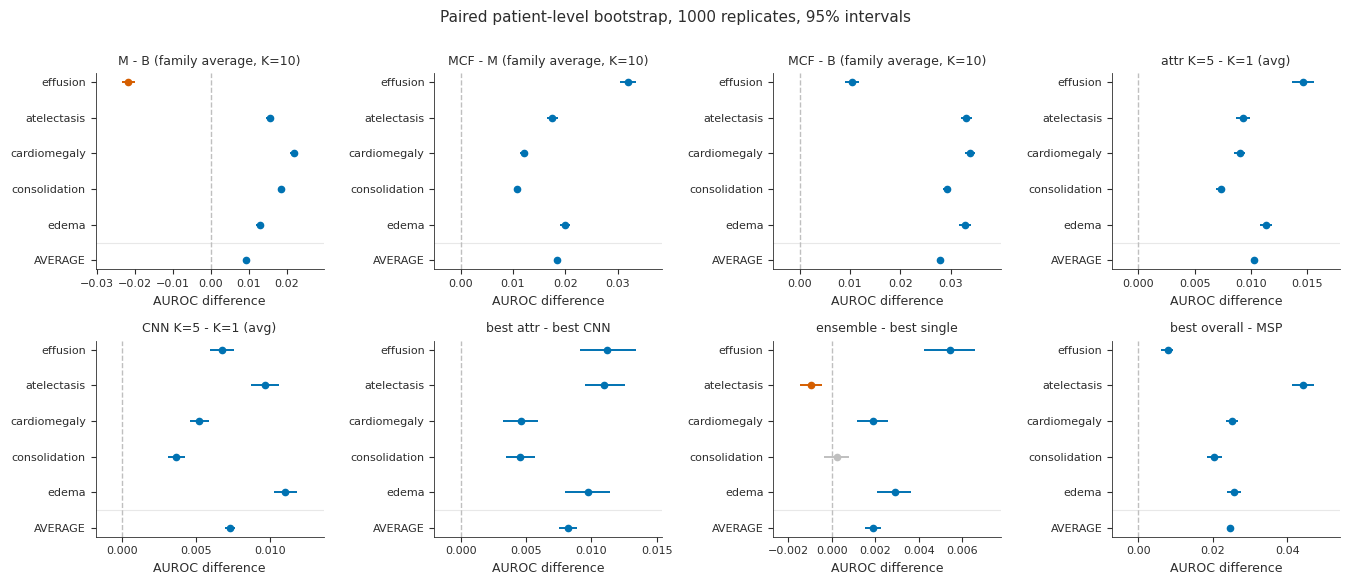

In [9]:
def cmp_forest(deltas=None, names=None, ncols=4, panel=(3.4, 2.9)):
    """Same reading as the forest in section 4, laid out as a grid over the comparisons."""
    deltas = CMP_DELTAS if deltas is None else deltas
    names  = names or CMP_NAMES
    order  = DISEASES + ["AVERAGE"]
    nrows  = int(np.ceil(len(names) / ncols))
    # NOT sharex: see the note above -- the deltas differ by two orders of magnitude.
    fig, axes = plt.subplots(nrows, ncols, figsize=(panel[0] * ncols, panel[1] * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, name in zip(axes, names):
        g = deltas[deltas.comparison == name].set_index("disease").loc[order]
        y = np.arange(len(order))[::-1]
        ax.axvline(0, color=GREY, ls="--", lw=1.0, zorder=1)
        ax.axhline(0.5, color=HAIR, lw=0.8, zorder=0)          # AVERAGE set apart
        for yi, (_, r) in zip(y, g.iterrows()):
            c = BLUE if r.lo > 0 else VERM if r.hi < 0 else GREY
            ax.plot([r.lo, r.hi], [yi, yi], color=c, lw=1.4, solid_capstyle="butt", zorder=2)
            ax.plot(r.delta, yi, "o", ms=4.5, color=c, zorder=3)
        # Always keep zero in view, with a margin, so a whisker that clears it is visible
        # as clearing it rather than being clipped at the edge of the panel.
        span = max(g.hi.max(), 0) - min(g.lo.min(), 0)
        ax.set_xlim(min(g.lo.min(), 0) - 0.15 * span, max(g.hi.max(), 0) + 0.15 * span)
        ax.set_yticks(y, order)
        
        # Inject the K value into the title for the family average comparisons
        display_name = name.replace("(family average)", f"(family average, K={K_AVG})")
        ax.set_title(display_name, color=INK, fontsize=9)
        
        ax.set_xlabel("AUROC difference")
        ax.tick_params(labelbottom=True)

    for ax in axes[len(names):]:
        ax.axis("off")
    fig.suptitle(f"Paired patient-level bootstrap, {N_BOOT} replicates, 95% intervals",
                 y=1.0, fontsize=11, color=INK)
    fig.tight_layout()
    return fig

cmp_forest();

In [10]:
# Revert cmp_forest back to the original version without text annotations, 
# then run this to generate the companion table:

summary_rows = []
for d in DISEASES:
    summary_rows.append({
        "Pathology": d,
        "Best Attribute": CMP_PICKS[d]["best_attr"],
        "Best CNN": CMP_PICKS[d]["best_cnn"],
        "Best Ensemble": CMP_PICKS[d]["best_ens"],
        "Best Overall": CMP_PICKS[d]["best_all"]
    })

companion_table = pd.DataFrame(summary_rows).set_index("Pathology")
companion_table.index.name = None  # Cleans up the print output

# Print formatted table 
companion_table

,Best Attribute,Best CNN,Best Ensemble,Best Overall
effusion,MCF5@K10,CNN dual_sal_scalars@K10,ENS rank@K10,ENS rank@K10
atelectasis,MCF1@K10,CNN dual_sal_scalars@K10,ENS lr@K10,MCF1@K10
cardiomegaly,MCF4@K10,CNN dual_sal_scalars@K10,ENS rank@K10,ENS rank@K10
consolidation,MCF1@K10,CNN dual_sal_scalars@K10,ENS rank@K10,MCF1@K10
edema,MCF5@K10,CNN dual_sal@K10,ENS rank@K10,ENS rank@K10


## 7.5 Verdict

Printed from the numbers rather than written down, so it cannot drift from the run above.
`HOLDS` means the 95% interval on the disease average is entirely above zero, `REVERSED`
entirely below, and `INCONCLUSIVE` that it straddles. The per-disease count says how many of
the five point the same way as the average -- a comparison can hold on average and still fail
on a disease.

In [11]:
for name in CMP_NAMES:
    g   = CMP_DELTAS[CMP_DELTAS.comparison == name].set_index("disease")
    avg, per = g.loc["AVERAGE"], g.loc[DISEASES]
    verdict = "HOLDS" if avg.lo > 0 else "REVERSED" if avg.hi < 0 else "INCONCLUSIVE"
    agree   = int((per.lo > 0).sum() if avg.delta > 0 else (per.hi < 0).sum())
    print(f"{name:<26} {verdict:<13} average {avg.delta:+.4f} "
          f"[{avg.lo:+.4f}, {avg.hi:+.4f}]  P(>0)={avg['P(delta>0)']:.1%}  "
          f"| same sign, interval clears 0 on {agree}/{len(DISEASES)} diseases")

M - B (family average)     HOLDS         average +0.0093 [+0.0089, +0.0098]  P(>0)=100.0%  | same sign, interval clears 0 on 4/5 diseases
MCF - M (family average)   HOLDS         average +0.0185 [+0.0180, +0.0189]  P(>0)=100.0%  | same sign, interval clears 0 on 5/5 diseases
MCF - B (family average)   HOLDS         average +0.0278 [+0.0273, +0.0283]  P(>0)=100.0%  | same sign, interval clears 0 on 5/5 diseases
attr K=5 - K=1 (avg)       HOLDS         average +0.0103 [+0.0100, +0.0106]  P(>0)=100.0%  | same sign, interval clears 0 on 5/5 diseases
CNN K=5 - K=1 (avg)        HOLDS         average +0.0073 [+0.0069, +0.0076]  P(>0)=100.0%  | same sign, interval clears 0 on 5/5 diseases
best attr - best CNN       HOLDS         average +0.0082 [+0.0075, +0.0089]  P(>0)=100.0%  | same sign, interval clears 0 on 5/5 diseases
ensemble - best single     HOLDS         average +0.0019 [+0.0015, +0.0023]  P(>0)=100.0%  | same sign, interval clears 0 on 3/5 diseases
best overall - MSP         HOLDS  